# 데이터 확인 및 준비하기

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

from tqdm import tqdm

# 결측치 확인
import missingno as msno

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

# # 지도
# # from geopy import distance # 거리 계산
# # import geopy.distance
# import folium
# from folium.plugins import HeatMap

# # plotly
# import ipywidgets as widgets
# from ipywidgets import interact

# # 이걸 설정하면 Multiple Output이 가능함
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = "all"

# import chart_studio.plotly as py 
# import plotly.express as px
# import cufflinks as cf 
# cf.go_offline(connected=True)

# import plotly.graph_objects as go

## 데이터 불러오기

In [46]:
df = pd.read_csv('./dataset/OBS_ASOS_DD_20220410004008.csv', encoding='utf-8')
df.head()

,지점,지점명,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
일시,,,,,,,
2012-12-01,165,목포,2.9,-0.3,2200,6.0,32
2012-12-02,165,목포,4.8,0.3,1,10.4,1507
2012-12-03,165,목포,5.0,1.4,514,10.4,1438
2012-12-04,165,목포,3.0,0.9,2239,6.1,1257
2012-12-05,165,목포,3.0,-0.3,2204,8.0,1240


In [47]:
df.shape

(46195, 7)

In [48]:
# 결측치 확인
df.isnull().sum()

지점                0
지점명               0
평균기온(°C)         93
최저기온(°C)          1
최저기온 시각(hhmi)     0
최고기온(°C)          2
최고기온 시각(hhmi)     0
dtype: int64

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 46195 entries, 2012-12-01 to 2022-03-31
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   지점             46195 non-null  int64  
 1   지점명            46195 non-null  object 
 2   평균기온(°C)       46102 non-null  float64
 3   최저기온(°C)       46194 non-null  float64
 4   최저기온 시각(hhmi)  46195 non-null  int64  
 5   최고기온(°C)       46193 non-null  float64
 6   최고기온 시각(hhmi)  46195 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 2.8+ MB


In [9]:
df[df['일시']=='2012-12-01']

,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
0,165,목포,2012-12-01,2.9,-0.3,2200,6.0,32
3408,168,여수,2012-12-01,4.6,0.9,736,6.4,1513
6816,169,흑산도,2012-12-01,4.6,3.1,1140,8.2,28
10222,170,완도,2012-12-01,4.1,1.5,2244,8.1,1502
13628,174,순천,2012-12-01,1.5,-3.0,2203,8.1,1414
17036,175,진도(첨찰산),2012-12-01,0.8,-1.3,807,4.0,1323
19476,252,영광군,2012-12-01,0.6,-2.9,2348,5.4,1
22884,258,보성군,2012-12-01,3.1,-1.4,2141,8.6,1511
26292,259,강진군,2012-12-01,2.6,-1.7,2041,8.8,1350
29697,260,장흥,2012-12-01,2.8,-1.9,2103,8.8,1448


In [18]:
df1 = df.groupby('일시')['평균기온(°C)', '최저기온(°C)', '최고기온(°C)'].mean()
df1 = df1.reset_index()
df1

,일시,평균기온(°C),최저기온(°C),최고기온(°C)
0,2012-12-01,2.953846,-0.846154,7.530769
1,2012-12-02,5.038462,0.607692,10.553846
2,2012-12-03,5.184615,-0.030769,10.500000
3,2012-12-04,2.592308,0.038462,5.876923
4,2012-12-05,2.976923,-0.876923,8.661538
...,...,...,...,...
3403,2022-03-27,10.023077,5.115385,17.246154
3404,2022-03-28,8.115385,2.923077,13.800000
3405,2022-03-29,9.753846,2.415385,17.153846
3406,2022-03-30,13.353846,5.653846,20.315385


In [20]:
# 일시 컬럼 날짜 타입으로 변경
df1['일시'] = pd.to_datetime(df1['일시'])

In [23]:
# 년월, 월 컬럼 생성

# 년월
df1['년월'] = df1['일시'].dt.strftime('%Y-%m')
# 월
df1['월'] = df1['일시'].dt.strftime('%m')

df1.head()

,일시,평균기온(°C),최저기온(°C),최고기온(°C),년월,월
0,2012-12-01,2.953846,-0.846154,7.530769,2012-12,12
1,2012-12-02,5.038462,0.607692,10.553846,2012-12,12
2,2012-12-03,5.184615,-0.030769,10.500000,2012-12,12
3,2012-12-04,2.592308,0.038462,5.876923,2012-12,12
4,2012-12-05,2.976923,-0.876923,8.661538,2012-12,12


In [26]:
df2 = df1.groupby('년월')['평균기온(°C)', '최저기온(°C)', '최고기온(°C)'].mean()
df2 = df2.reset_index()
df2.head()

,년월,평균기온(°C),최저기온(°C),최고기온(°C)
0,2012-12,1.444417,-2.361538,5.608933
1,2013-01,0.652854,-3.363027,5.113151
2,2013-02,2.374725,-1.940110,6.986264
3,2013-03,7.082630,1.300744,13.758809
4,2013-04,10.622821,5.184615,16.343333


In [39]:
df2['년월'] = pd.to_datetime(df2['년월'])
df2['월'] = df2['년월'].dt.month
df2['년월'] = df2['년월'].dt.strftime('%Y-%m')
df2

,년월,평균기온(°C),최저기온(°C),최고기온(°C),월
0,2012-12,1.444417,-2.361538,5.608933,12
1,2013-01,0.652854,-3.363027,5.113151,1
2,2013-02,2.374725,-1.940110,6.986264,2
3,2013-03,7.082630,1.300744,13.758809,3
4,2013-04,10.622821,5.184615,16.343333,4
...,...,...,...,...,...
107,2021-11,10.296154,5.505641,16.116410,11
108,2021-12,4.315881,-0.321588,9.648139,12
109,2022-01,1.872002,-2.288337,6.771464,1
110,2022-02,2.004281,-2.671223,7.068864,2


In [40]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   년월        112 non-null    object 
 1   평균기온(°C)  112 non-null    float64
 2   최저기온(°C)  112 non-null    float64
 3   최고기온(°C)  112 non-null    float64
 4   월         112 non-null    int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 4.5+ KB


In [69]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/a10.csv',
parse_dates=['date'], index_col='date')
df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


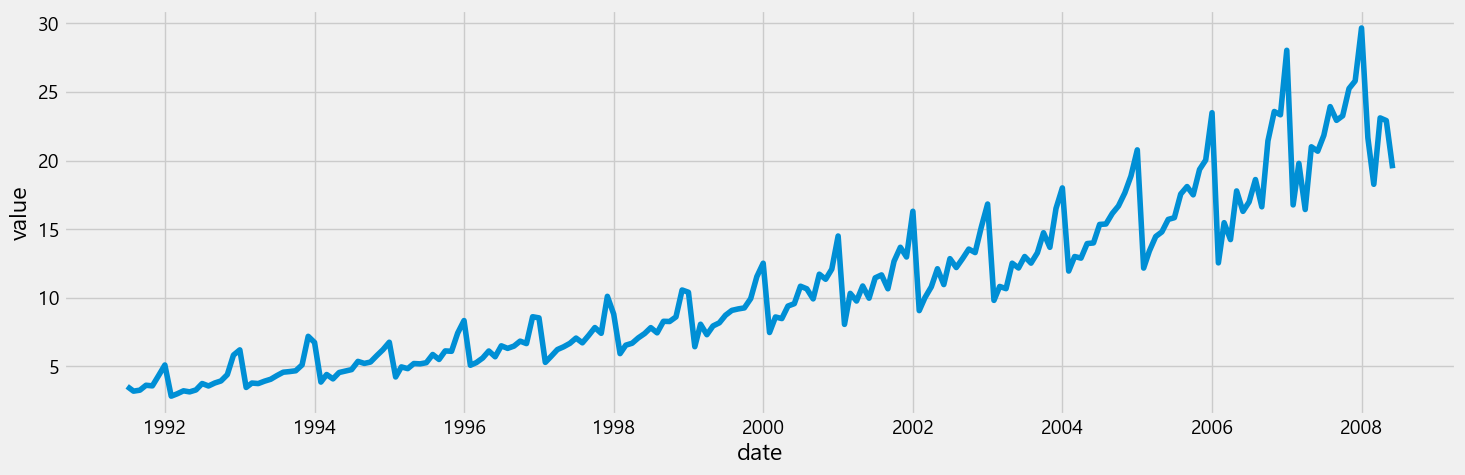

In [73]:
plt.figure(figsize=(16, 5), dpi=100)
sns.lineplot(x=df.index, y=df.value)
plt.show()

In [50]:
df = pd.read_csv('./dataset/OBS_ASOS_DD_20220410004008.csv',parse_dates=['일시'], index_col='일시', encoding='utf-8')
df.head()

,지점,지점명,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
일시,,,,,,,
2012-12-01,165,목포,2.9,-0.3,2200,6.0,32
2012-12-02,165,목포,4.8,0.3,1,10.4,1507
2012-12-03,165,목포,5.0,1.4,514,10.4,1438
2012-12-04,165,목포,3.0,0.9,2239,6.1,1257
2012-12-05,165,목포,3.0,-0.3,2204,8.0,1240


In [75]:
df = pd.read_csv('./dataset/OBS_ASOS_DD_20220410004008.csv', parse_dates=['일시'], encoding='utf-8')
df.head()

,지점,지점명,일시,평균기온(°C),최저기온(°C),최저기온 시각(hhmi),최고기온(°C),최고기온 시각(hhmi)
0,165,목포,2012-12-01,2.9,-0.3,2200,6.0,32
1,165,목포,2012-12-02,4.8,0.3,1,10.4,1507
2,165,목포,2012-12-03,5.0,1.4,514,10.4,1438
3,165,목포,2012-12-04,3.0,0.9,2239,6.1,1257
4,165,목포,2012-12-05,3.0,-0.3,2204,8.0,1240


In [76]:
df1 = df.groupby('일시')['평균기온(°C)', '최저기온(°C)', '최고기온(°C)'].mean()
df1.columns = ['평균기온', '최저기온', '최고기온']
df1

,평균기온,최저기온,최고기온
일시,,,
2012-12-01,2.953846,-0.846154,7.530769
2012-12-02,5.038462,0.607692,10.553846
2012-12-03,5.184615,-0.030769,10.500000
2012-12-04,2.592308,0.038462,5.876923
2012-12-05,2.976923,-0.876923,8.661538
...,...,...,...
2022-03-27,10.023077,5.115385,17.246154
2022-03-28,8.115385,2.923077,13.800000
2022-03-29,9.753846,2.415385,17.153846


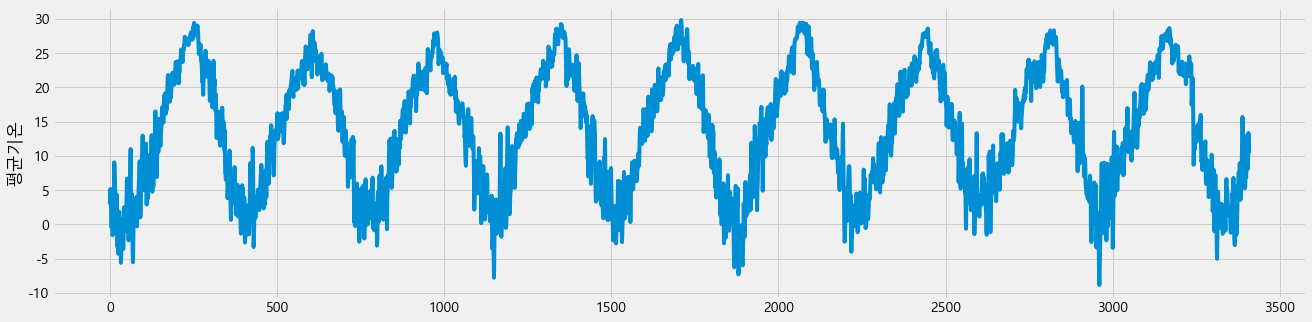

In [88]:
plt.figure(figsize=(20,5))
sns.lineplot(x=df1.index, y=df1['평균기온'], data=df1)
plt.show()

In [85]:
df1 = df1.reset_index()
df1['year'] = df1['일시'].dt.year
df1['month'] = df1['일시'].dt.month
df1

,일시,평균기온,최저기온,최고기온,year,month
0,2012-12-01,2.953846,-0.846154,7.530769,2012,12
1,2012-12-02,5.038462,0.607692,10.553846,2012,12
2,2012-12-03,5.184615,-0.030769,10.500000,2012,12
3,2012-12-04,2.592308,0.038462,5.876923,2012,12
4,2012-12-05,2.976923,-0.876923,8.661538,2012,12
...,...,...,...,...,...,...
3403,2022-03-27,10.023077,5.115385,17.246154,2022,3
3404,2022-03-28,8.115385,2.923077,13.800000,2022,3
3405,2022-03-29,9.753846,2.415385,17.153846,2022,3
3406,2022-03-30,13.353846,5.653846,20.315385,2022,3


In [87]:
years = df1['year'].unique()
years

array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
      dtype=int64)

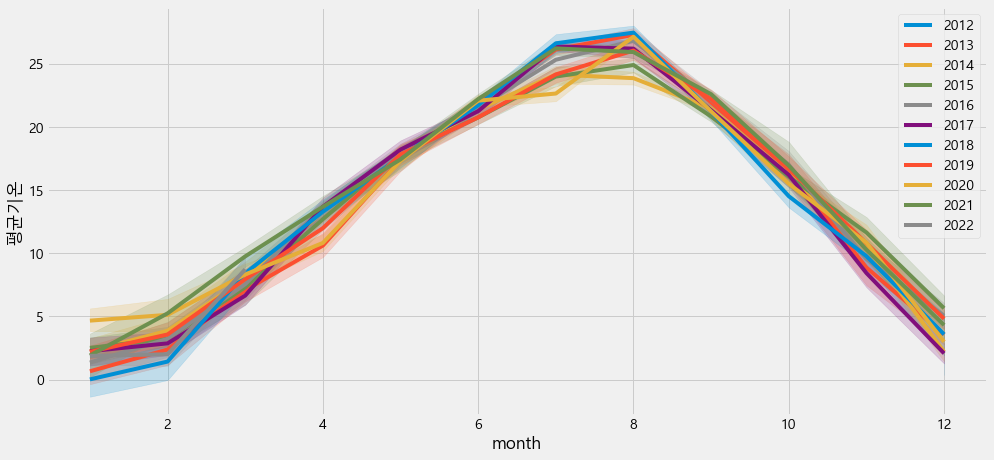

In [94]:
plt.figure(figsize=(15, 7))
for i, y in enumerate(years):
    sns.lineplot('month', '평균기온', data=df1[df1.year==y], label=y)
    
plt.show()

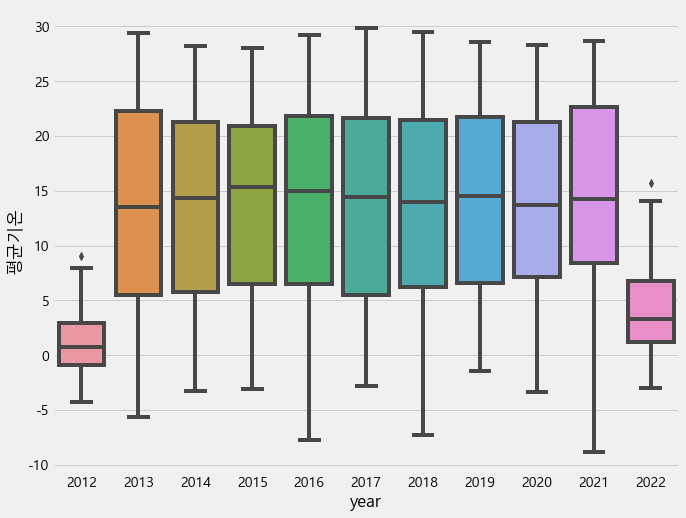

In [97]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df1)
plt.show()

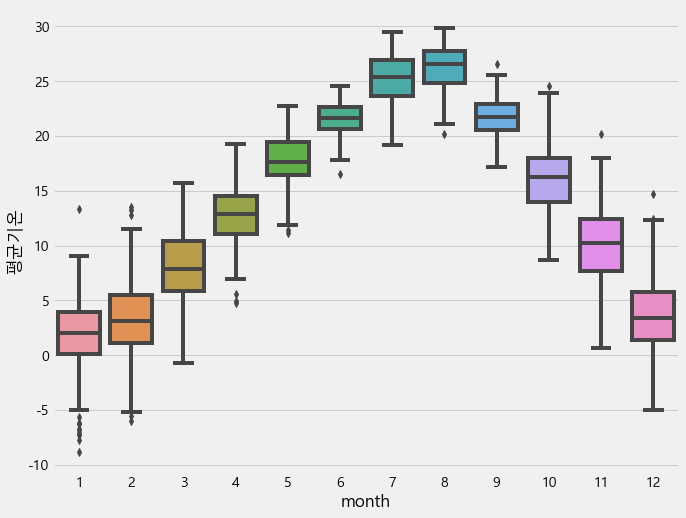

In [98]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='month', y='평균기온', data=df1)
plt.show()

In [99]:
df1

,일시,평균기온,최저기온,최고기온,year,month
0,2012-12-01,2.953846,-0.846154,7.530769,2012,12
1,2012-12-02,5.038462,0.607692,10.553846,2012,12
2,2012-12-03,5.184615,-0.030769,10.500000,2012,12
3,2012-12-04,2.592308,0.038462,5.876923,2012,12
4,2012-12-05,2.976923,-0.876923,8.661538,2012,12
...,...,...,...,...,...,...
3403,2022-03-27,10.023077,5.115385,17.246154,2022,3
3404,2022-03-28,8.115385,2.923077,13.800000,2022,3
3405,2022-03-29,9.753846,2.415385,17.153846,2022,3
3406,2022-03-30,13.353846,5.653846,20.315385,2022,3


## 12월

In [107]:
df2 = df1[df1['month']==12]
df2

,일시,평균기온,최저기온,최고기온,year,month
0,2012-12-01,2.953846,-0.846154,7.530769,2012,12
1,2012-12-02,5.038462,0.607692,10.553846,2012,12
2,2012-12-03,5.184615,-0.030769,10.500000,2012,12
3,2012-12-04,2.592308,0.038462,5.876923,2012,12
4,2012-12-05,2.976923,-0.876923,8.661538,2012,12
...,...,...,...,...,...,...
3313,2021-12-27,-1.946154,-7.738462,2.646154,2021,12
3314,2021-12-28,2.884615,-1.438462,7.276923,2021,12
3315,2021-12-29,4.800000,-0.146154,9.623077,2021,12
3316,2021-12-30,2.915385,0.615385,5.607692,2021,12


### 평균기온

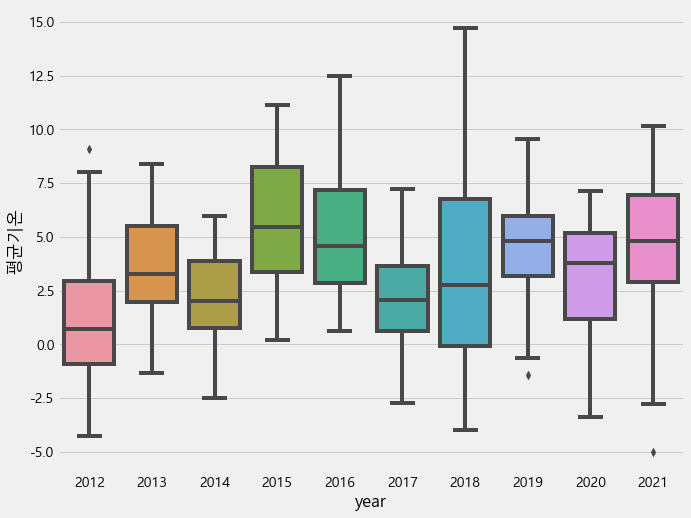

In [102]:
# 12월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

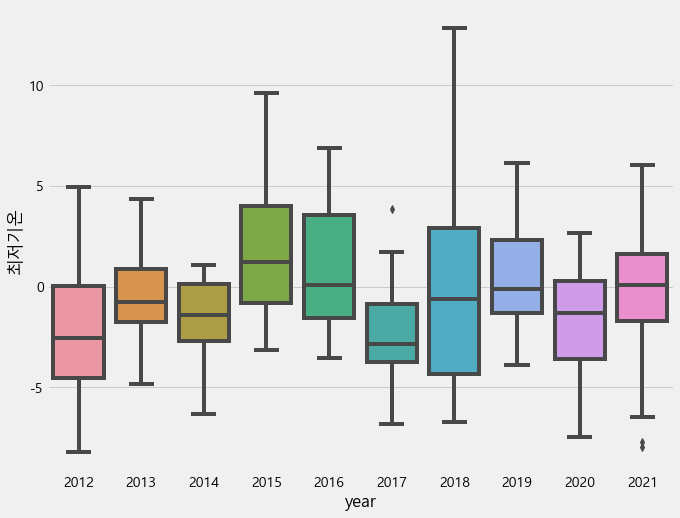

In [108]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

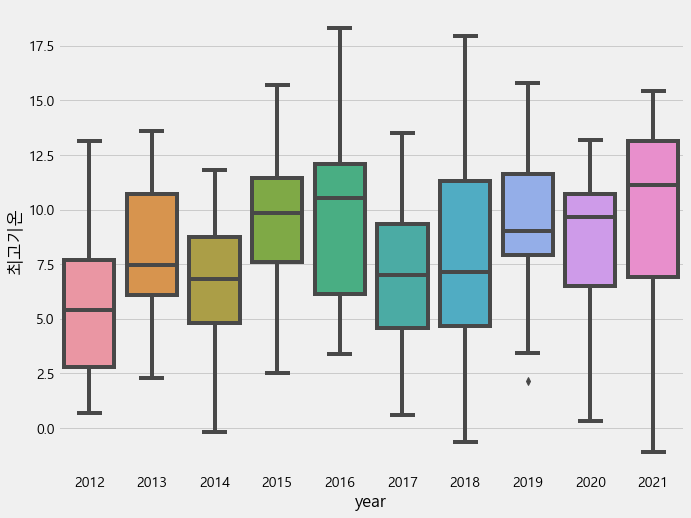

In [109]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

## 1월

In [110]:
df2 = df1[df1['month']==1]
df2

,일시,평균기온,최저기온,최고기온,year,month
31,2013-01-01,0.830769,-4.538462,5.892308,2013,1
32,2013-01-02,-1.453846,-6.207692,3.676923,2013,1
33,2013-01-03,-5.600000,-8.115385,-2.246154,2013,1
34,2013-01-04,-4.376923,-7.853846,0.423077,2013,1
35,2013-01-05,-2.123077,-7.130769,2.830769,2013,1
...,...,...,...,...,...,...
3344,2022-01-27,3.192308,0.769231,7.353846,2022,1
3345,2022-01-28,1.923077,-0.246154,5.915385,2022,1
3346,2022-01-29,1.346154,-0.384615,5.023077,2022,1
3347,2022-01-30,1.384615,-1.530769,5.976923,2022,1


### 평균기온

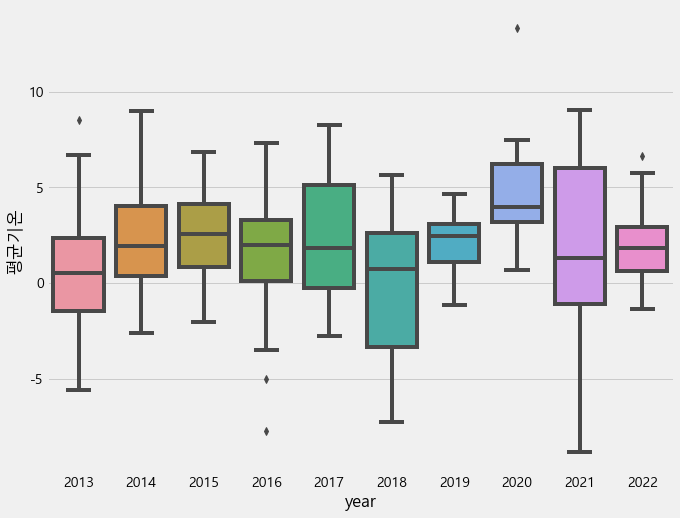

In [104]:
# 1월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

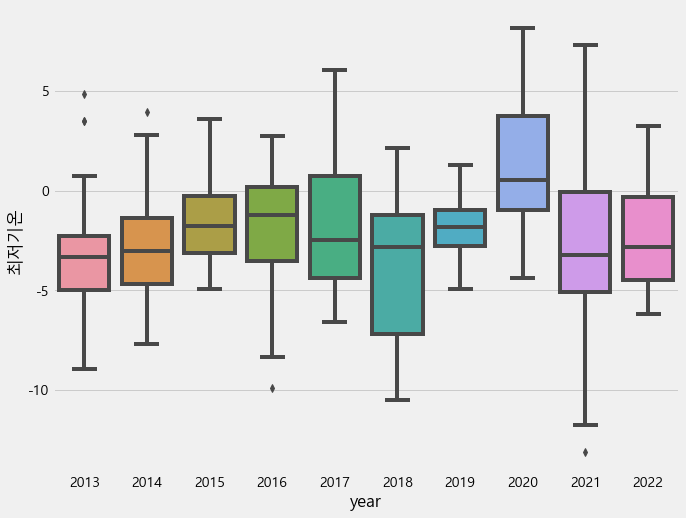

In [111]:
# 1월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

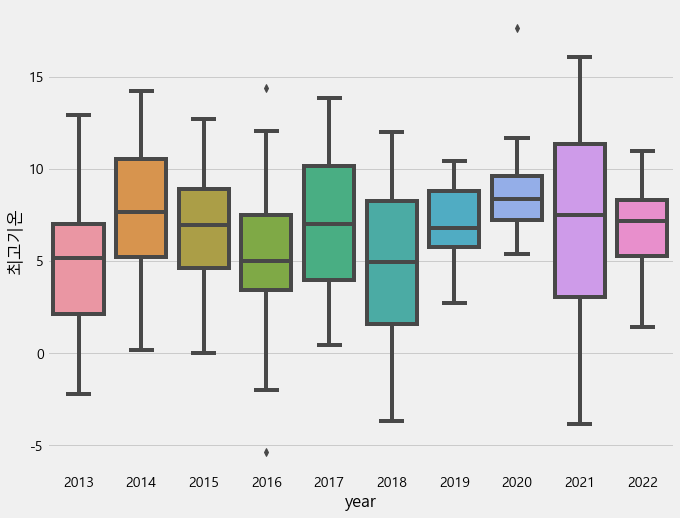

In [112]:
# 1월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

## 2월

In [113]:
df2 = df1[df1['month']==2]
df2.head()

,일시,평균기온,최저기온,최고기온,year,month
62,2013-02-01,11.000000,6.930769,15.223077,2013,2
63,2013-02-02,3.469231,-0.730769,7.692308,2013,2
64,2013-02-03,2.400000,-2.923077,6.707692,2013,2
65,2013-02-04,4.546154,0.800000,8.876923,2013,2
66,2013-02-05,3.007692,-0.246154,5.407692,2013,2


### 평균기온

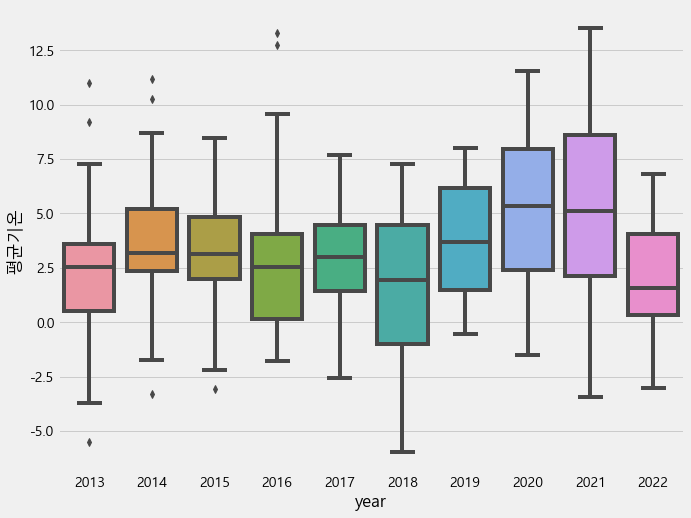

In [106]:
# 2월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

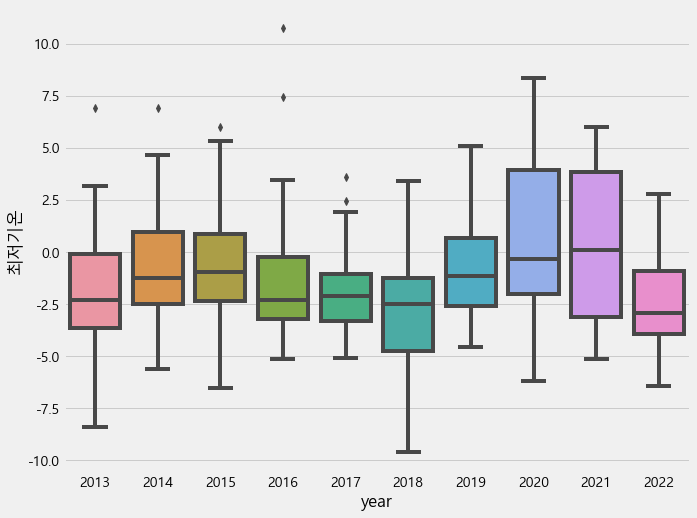

In [114]:
# 2월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

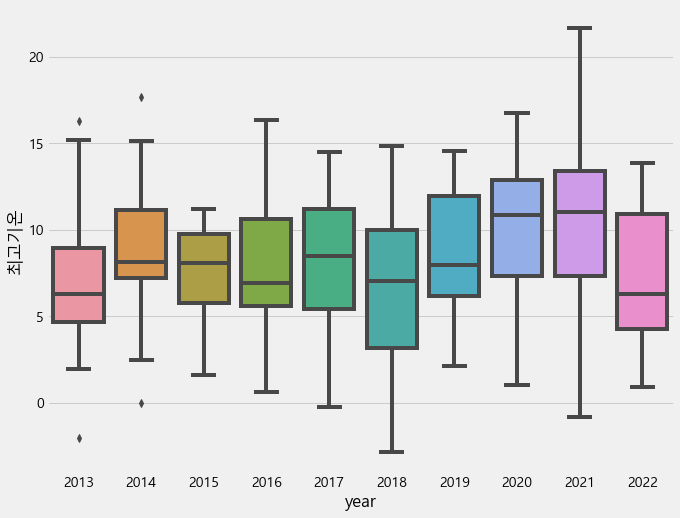

In [115]:
# 2월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

## 3월

In [116]:
df2 = df1[df1['month']==3]
df2.head()

,일시,평균기온,최저기온,최고기온,year,month
90,2013-03-01,4.130769,-0.623077,12.569231,2013,3
91,2013-03-02,1.046154,-1.700000,5.461538,2013,3
92,2013-03-03,1.815385,-3.138462,7.346154,2013,3
93,2013-03-04,4.638462,-2.184615,12.400000,2013,3
94,2013-03-05,4.930769,-1.800000,13.292308,2013,3


### 평균기온

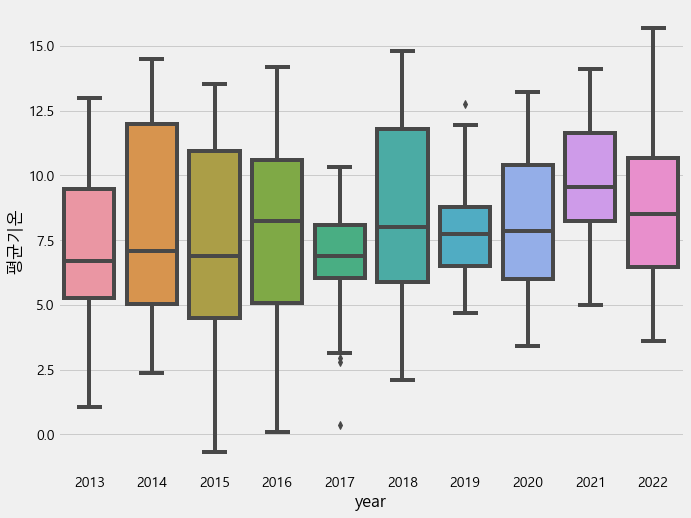

In [117]:
# 3월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='평균기온', data=df2)
plt.show()

### 최저기온

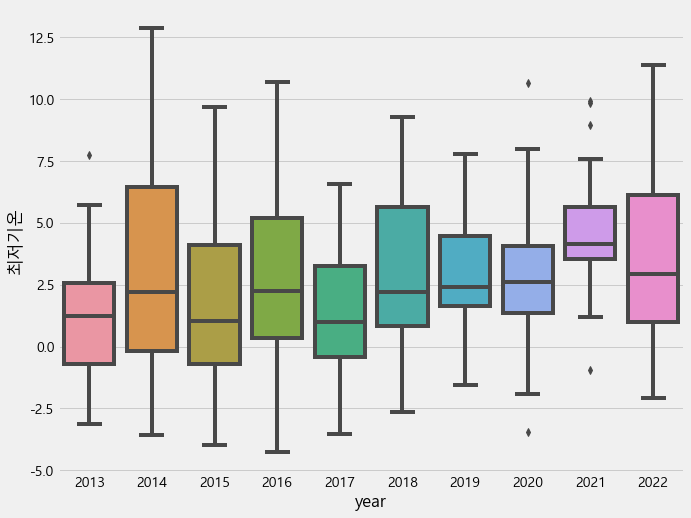

In [118]:
# 3월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최저기온', data=df2)
plt.show()

### 최고기온

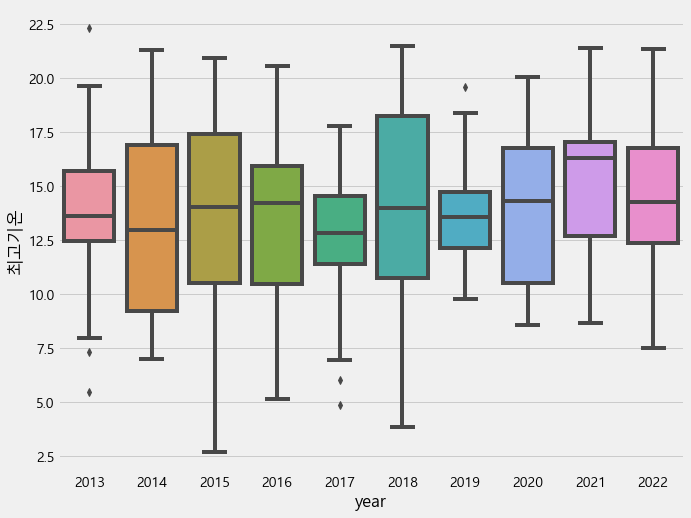

In [119]:
# 3월
plt.figure(figsize=(10, 8))
sns.boxplot(x='year', y='최고기온', data=df2)
plt.show()

In [ ]:
plt.figure(figsize=(15, 7))
for i, y in enumerate(years):
    sns.lineplot('month', '평균기온', data=df1[df1.year==y], label=y)
    
plt.show()